In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
from matplotlib import pyplot as plt
plt.rcParams['font.family']='Times New Roman,Microsoft YaHei'# 设置字体族，中文为微软雅黑，英文为Times New Roman
plt.rcParams['mathtext.fontset'] = 'stix' # 设置数%matplotlib qt学公式字体为stix
plt.style.use('seaborn-v0_8-paper')
# 设置全局参数
plt.rcParams['figure.facecolor'] = 'white'  # 设置图形的背景为透明
plt.rcParams['axes.facecolor'] = 'white'    # 设置轴域的背景为透明
plt.rcParams['savefig.facecolor'] = 'white' # 保存图像时背景透明
import matplotlib
# matplotlib.use('TkAgg')
%matplotlib inline

In [2]:
df=pd.read_pickle("basic_var.pkl")

In [3]:
dffile=pd.read_pickle('fileinformation.pkl')

In [4]:
df.columns

Index(['Date', 'place', 'level', 'NDSI', 'ADI', 'ACI', 'RAOQ', 'AnthroEnergy',
       'rBA', 'BioEnergy', 'BI', 'AEI', 'H_pairedShannon'],
      dtype='object')

In [4]:
# 去除重复列
df = df.loc[:, ~df.columns.duplicated()]

# 定义高度替换规则
def replace_level(row):
    if row['place'] == 'ZS':
        return '3 m' if row['level'] == 1 else f"{row['level']}m"
    elif row['place'] == 'JH':
        return {1: '1.5 m', 2: '4 m', 3: '8 m', 4: '14 m'}.get(row['level'], f"{row['level']}m")
    elif row['place'] == 'CM':
        return {1: '1.5 m', 2: '10 m', 3: '16 m', 4: '22 m'}.get(row['level'], f"{row['level']}m")
    return f"{row['level']}m"

# 替换 level 列的值
df['level'] = df.apply(replace_level, axis=1)

In [5]:
# 去除重复列
dffile = dffile.loc[:, ~dffile.columns.duplicated()]

# 定义高度替换规则
def replace_level(row):
    if row['place'] == 'ZS':
        return '3 m' if row['level'] == 1 else f"{row['level']}m"
    elif row['place'] == 'JH':
        return {1: '1.5 m', 2: '4 m', 3: '8 m', 4: '14 m'}.get(row['level'], f"{row['level']}m")
    elif row['place'] == 'CM':
        return {1: '1.5 m', 2: '10 m', 3: '16 m', 4: '22 m'}.get(row['level'], f"{row['level']}m")
    return f"{row['level']}m"

# 替换 level 列的值
dffile['level'] = dffile.apply(replace_level, axis=1)

In [7]:
from sklearn.preprocessing import StandardScaler
from annoy import AnnoyIndex


def prepare_data(df, numeric_columns):
    # 标准化这些列，但不修改原始DataFrame
    scaler = StandardScaler()
    df_normalized = scaler.fit_transform(df[numeric_columns])
    df_normalized = pd.DataFrame(df_normalized, columns=numeric_columns, index=df.index)

    return df_normalized

# def find_similar_records(df, numeric_columns, n_trees=10, search_k=-1, n_neighbors=10):
#     f = len(numeric_columns)  # 维度数等于你的数值列数量
#     t = AnnoyIndex(f, 'euclidean')  # 使用欧几里得距离
# 
#     # 将数据添加到Annoy索引
#     for i in range(len(df)):
#         t.add_item(i, df.loc[i, numeric_columns].values)
# 
#     t.build(n_trees)  # 构建索引树
# 
#     # 查找每个项目的近似最近邻
#     similar_pairs = []
#     for i in range(len(df)):
#         nearest = t.get_nns_by_item(i, n_neighbors, search_k=search_k)  # 找到最近的n_neighbors个邻居
#         for j in nearest:
#             if i != j and df.loc[i, 'Date'] != df.loc[j, 'Date']:
#                 similar_pairs.append((i, j))
# 
#     # 返回相似对的DataFrame表示
#     return df.loc[[idx for pair in similar_pairs for idx in pair]]


def find_similar_records(df, df_normalized, numeric_columns, n_trees=1000, search_k=-1, n_neighbors=10, target_pairs=50):
    f = len(numeric_columns)  # 维度数等于数值列数量
    t = AnnoyIndex(f, 'euclidean')  # 使用欧几里得距离

    # 将标准化数据添加到Annoy索引
    for i in df_normalized.index:
        t.add_item(i, df_normalized.loc[i].values)

    t.build(n_trees)  # 构建索引树

    # 查找每个项目的近似最近邻，并存储距离
    similar_pairs = []
    for i in range(len(df)):
        nearest = t.get_nns_by_item(i, n_neighbors, search_k=search_k, include_distances=True)  # 返回最近邻及其距离
        for j, dist in zip(nearest[0], nearest[1]):
            if i != j and df.loc[i, 'Date'] != df.loc[j, 'Date']:
                similar_pairs.append((i, j))
                # 如果达到目标对数，提前退出
                if len(similar_pairs) >= target_pairs:
                    return df.loc[[idx for pair in similar_pairs for idx in pair]]

    # 如果没有足够的对数，返回已找到的所有对
    return df.loc[[idx for pair in similar_pairs for idx in pair]]

In [ ]:
# 选择要比较的数值列
# numeric_columns = ['NDSI', 'ADI', 'ACI', 'RAOQ', 'AnthroEnergy','rBA', 'BioEnergy', 'BI', 'AEI', 'H_pairedShannon']
numeric_columns = ['NDSI', 'ADI', 'ACI', 'RAOQ', 'H_pairedShannon']
df_normalized = prepare_data(df, numeric_columns)
similar_records_df = find_similar_records(df, df_normalized, numeric_columns, target_pairs=100)

In [ ]:
similar_records_df

In [ ]:
dffile[(dffile.Date=='2023-09-24 00:00:00')*(dffile.place=='CM')*(dffile.level=='16 m')]

In [ ]:
dffile[(dffile.Date == '2023-02-11 13:00:00') * (dffile.place == 'JH')*(dffile.level=='1.5 m')]

In [ ]:
dffile[(dffile.Date=='2023-09-23 23:10:00')*(dffile.place=='CM')*(dffile.level=='16 m')]

In [ ]:
dffile[(dffile.Date == '2024-01-02 16:10:00') * (dffile.place == 'JH')*(dffile.level=='4 m')]

In [9]:
results = pd.concat([
    # df[(df['Date'] == '2023-09-24 00:00:00') & (df['place'] == 'CM') & (df['level'] == '16 m')],
    # df[(df['Date'] == '2023-02-11 13:00:00') & (df['place'] == 'JH') & (df['level'] == '1.5 m')],
    df[(df['Date'] == '2023-09-23 23:10:00') & (df['place'] == 'CM') & (df['level'] == '16 m')],
    df[(df['Date'] == '2024-01-02 16:10:00') & (df['place'] == 'JH') & (df['level'] == '4 m')]
])

In [ ]:
results

In [8]:
metrics=['ACI', 'RAOQ', 'NDSI', 'ADI', 'H_pairedShannon','AEI']
df_mean_std = pd.DataFrame({
    'Metric': metrics,
    'Mean': [df[metric].mean() for metric in metrics],
    'Std': [df[metric].std() for metric in metrics]
})
# 四舍五入到两位小数
df_mean_std['Mean'] = df_mean_std['Mean'].round(2)
df_mean_std['Std'] = df_mean_std['Std'].round(3)
# 创建一个新的列来展示 "均值(标准差)" 格式
df_mean_std['Mean(Std)'] = df_mean_std.apply(lambda x: f"{x['Mean']} ({x['Std']})", axis=1)
df_mean_std

,Metric,Mean,Std,Mean(Std)
0,ACI,307.83,21.401,307.83 (21.401)
1,RAOQ,0.03,0.089,0.03 (0.089)
2,NDSI,-0.95,0.174,-0.95 (0.174)
3,ADI,0.93,0.572,0.93 (0.572)
4,H_pairedShannon,2.44,0.562,2.44 (0.562)
5,AEI,0.69,0.195,0.69 (0.195)


In [2]:
from maad import sound, util, rois, features
from maad.rois import find_rois_cwt
from maad.util import plot_spectrogram
from maad.util import power2dB, plot2d
from skimage import transform
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import NMF
from maad.util import (
   power2dB, plot2d, format_features, read_audacity_annot,
   overlay_rois, overlay_centroid
   )
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from maad import sound, util
from maad.rois import template_matching

In [3]:
fileleft='CM3-S4A16367_20230923_231000.wav'
fileright='JH2-S4A16399_20240102_161000.wav'

In [4]:
s, fs = sound.load(fileleft)
Sxx, tn, fn, ext = sound.spectrogram(s, fs, nperseg=1024, noverlap=512)
Sxx_db = power2dB(Sxx, db_range=70)
Sxx_db = transform.rescale(Sxx_db, 0.5, anti_aliasing=True, channel_axis=None)  # rescale for faster computation # multichannel=False change by  channel_axis=None

shape_im, params = features.shape_features_raw(Sxx_db, resolution='low')
# Format the output as an array for decomposition
X = np.array(shape_im).reshape([len(shape_im), Sxx_db.size]).transpose()
# Decompose signal using non-negative matrix factorization
Y = NMF(n_components=3, init='random', random_state=0).fit_transform(X)
Y = MinMaxScaler(feature_range=(0,1)).fit_transform(Y)
intensity = 1 - (Sxx_db - Sxx_db.min()) / (Sxx_db.max() - Sxx_db.min())
plt_data = Y.reshape([Sxx_db.shape[0], Sxx_db.shape[1], 3])
plt_data = np.dstack((plt_data, intensity))

# Set spectrogram parameters
tlims = (9.8, 10.5)
flims = (2000, 8000)
nperseg = 1024
noverlap = 512
window = 'hann'
db_range = 80
# Compute spectrogram for template signal
Sxx_template, _, _, _ = sound.spectrogram(s, fs, window, nperseg, noverlap, flims, tlims)
Sxx_template = util.power2dB(Sxx_template, db_range)
# Compute spectrogram for target audio
Sxx_audio, tn, fn, ext = sound.spectrogram(s, fs, window, nperseg, noverlap, flims)
Sxx_audio = util.power2dB(Sxx_audio, db_range)
peak_th = 0.4 # set the threshold to find peaks
xcorrcoef, rois = template_matching(Sxx_audio, Sxx_template, tn, ext, peak_th)
rois['min_f'] = flims[0]
rois['max_f'] = flims[1]
_, _, fnp, _ = sound.spectrogram(s, fs, window, nperseg, noverlap)

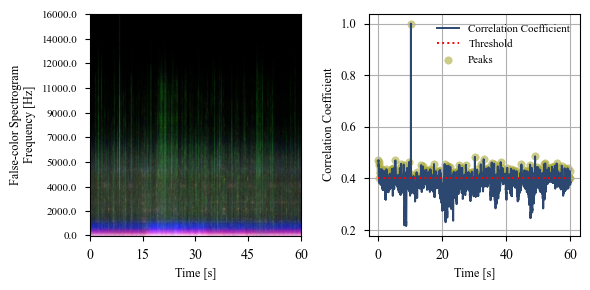

In [5]:
from palettable.scientific.sequential import Batlow_8
# 创建图形
fig, ax = plt.subplots(1, 2, figsize=(6, 3))

# 绘制假色频谱图
cmap = Batlow_8.mpl_colormap
im = ax[0].imshow(plt_data, origin='lower', aspect='auto', interpolation='bilinear', cmap=cmap)
ax[0].set_ylabel('False-color Spectrogram\nFrequency [Hz]')
ax[0].set_xlabel('Time [s]')
ax[0].set_title('')
y_ticks = np.linspace(0, plt_data.shape[0] - 1, num=10, dtype=int)  # 选择 10 个刻度位置
y_quantiles = np.linspace(0, 1, len(y_ticks))  # 计算 y_ticks 的分位数
fnp_quantiles = np.quantile(fnp, y_quantiles)  # 根据 y_ticks 的分位数获取 fnp 的相应值
mapped_values = np.interp(y_quantiles, y_quantiles, fnp_quantiles)
freq_labels = mapped_values = np.interp(y_quantiles, y_quantiles, fnp_quantiles)
freq_labels = np.round(freq_labels / 1000) * 1000  # 将频率标签四舍五入为 1000 的倍数
# 设置 y 轴的刻度位置和标签
ax[0].set_yticks(y_ticks)
ax[0].set_yticklabels(np.round(freq_labels, decimals=2))  # 四舍五入到两位小数
ax[0].grid(False)


# 设置 x 轴为秒数
total_time = 60  
time_per_pixel = total_time / plt_data.shape[1]
time_sec = np.linspace(0, plt_data.shape[1] * time_per_pixel, plt_data.shape[1])  # 每个像素对应的时间间隔
x_ticks = np.linspace(0, plt_data.shape[1] - 1, num=5, dtype=int) 
time_labels = np.interp(x_ticks, np.arange(len(time_sec)), time_sec)  # 插值刻度标签为秒数
ax[0].set_xticks(x_ticks)
ax[0].set_xticklabels(np.round(time_labels, decimals=0).astype(int))  # 将时间标签四舍五入为两位小数

# 绘制相关系数图
ax[1].plot(tn[0:len(xcorrcoef)], xcorrcoef, label='Correlation Coefficient',color='#2C4770')
ax[1].hlines(peak_th, 0, tn[-1], linestyle='dotted', color='red', label='Threshold')
# 使用scatter绘制散点图
ax[1].scatter(rois['peak_time'], rois['xcorrcoef'], color='#AAAA39', s=30, edgecolor=None, label='Peaks', alpha=0.6)
ax[1].set_xlabel('Time [s]')
ax[1].set_ylabel('Correlation Coefficient')
ax[1].legend(frameon=False)
ax[1].grid(True)
ax[0].tick_params(axis='x', labelsize=10)
ax[1].tick_params(axis='x', labelsize=10)
ax[0].tick_params(axis='y', labelsize=8)
ax[1].tick_params(axis='y', labelsize=9)

# 调整布局和保存
fig.tight_layout()
fig.savefig('CM D minor example.svg')
plt.show()

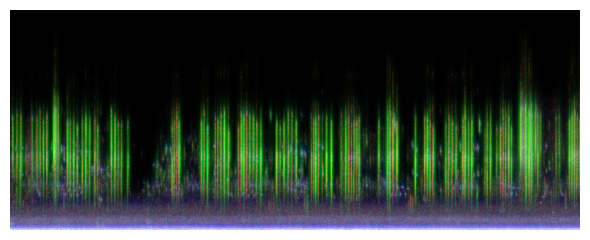

In [18]:
# 创建图形
fig, ax = plt.subplots(1, 1, figsize=(6, 2.5))

# 绘制假色频谱图
cmap = Batlow_8.mpl_colormap
im = ax.imshow(plt_data, origin='lower', aspect='auto', interpolation='bilinear', cmap=cmap)
ax.set_ylabel('')
ax.set_xlabel('')
ax.set_title('')
ax.grid(False)
# 关闭坐标轴和网格
ax.axis('off')     # 关闭坐标轴

# 调整布局和保存
fig.tight_layout()
fig.savefig('频谱示例.svg',transparent=True)
fig.savefig('频谱示例.jpg',dpi=400,transparent=True)
plt.show()

In [6]:
s, fs = sound.load(fileright)
Sxx, tn, fn, ext = sound.spectrogram(s, fs, nperseg=1024, noverlap=512)
Sxx_db = power2dB(Sxx, db_range=70)
Sxx_db = transform.rescale(Sxx_db, 0.5, anti_aliasing=True, channel_axis=None)  # rescale for faster computation # multichannel=False change by  channel_axis=None

shape_im, params = features.shape_features_raw(Sxx_db, resolution='low')
# Format the output as an array for decomposition
X = np.array(shape_im).reshape([len(shape_im), Sxx_db.size]).transpose()
# Decompose signal using non-negative matrix factorization
Y = NMF(n_components=3, init='random', random_state=0).fit_transform(X)
Y = MinMaxScaler(feature_range=(0,1)).fit_transform(Y)
intensity = 1 - (Sxx_db - Sxx_db.min()) / (Sxx_db.max() - Sxx_db.min())
plt_data = Y.reshape([Sxx_db.shape[0], Sxx_db.shape[1], 3])
plt_data = np.dstack((plt_data, intensity))

# Set spectrogram parameters
tlims = (9.8, 10.5)
flims = (2000, 8000)
nperseg = 1024
noverlap = 512
window = 'hann'
db_range = 80
# Compute spectrogram for template signal
Sxx_template, _, _, _ = sound.spectrogram(s, fs, window, nperseg, noverlap, flims, tlims)
Sxx_template = util.power2dB(Sxx_template, db_range)
# Compute spectrogram for target audio
Sxx_audio, tn, fn, ext = sound.spectrogram(s, fs, window, nperseg, noverlap, flims)
Sxx_audio = util.power2dB(Sxx_audio, db_range)
peak_th = 0.3 # set the threshold to find peaks
xcorrcoef, rois = template_matching(Sxx_audio, Sxx_template, tn, ext, peak_th)
rois['min_f'] = flims[0]
rois['max_f'] = flims[1]
_, _, fnp, _ = sound.spectrogram(s, fs, window, nperseg, noverlap)

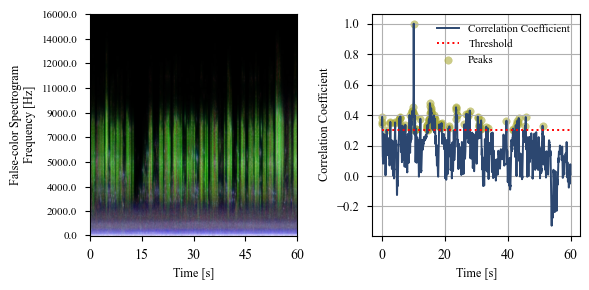

In [7]:
# 创建图形
fig, ax = plt.subplots(1, 2, figsize=(6, 3))

# 绘制假色频谱图
cmap = Batlow_8.mpl_colormap
im = ax[0].imshow(plt_data, origin='lower', aspect='auto', interpolation='bilinear', cmap=cmap)
ax[0].set_ylabel('False-color Spectrogram\nFrequency [Hz]')
ax[0].set_xlabel('Time [s]')
ax[0].set_title('')
y_ticks = np.linspace(0, plt_data.shape[0] - 1, num=10, dtype=int)  # 选择 10 个刻度位置
y_quantiles = np.linspace(0, 1, len(y_ticks))  # 计算 y_ticks 的分位数
fnp_quantiles = np.quantile(fnp, y_quantiles)  # 根据 y_ticks 的分位数获取 fnp 的相应值
mapped_values = np.interp(y_quantiles, y_quantiles, fnp_quantiles)
freq_labels = mapped_values = np.interp(y_quantiles, y_quantiles, fnp_quantiles)
freq_labels = np.round(freq_labels / 1000) * 1000  # 将频率标签四舍五入为 1000 的倍数
# 设置 y 轴的刻度位置和标签
ax[0].set_yticks(y_ticks)
ax[0].set_yticklabels(np.round(freq_labels, decimals=2))  # 四舍五入到两位小数
ax[0].grid(False)

# 设置 x 轴为秒数
total_time = 60  
time_per_pixel = total_time / plt_data.shape[1]
time_sec = np.linspace(0, plt_data.shape[1] * time_per_pixel, plt_data.shape[1])  # 每个像素对应的时间间隔
x_ticks = np.linspace(0, plt_data.shape[1] - 1, num=5, dtype=int) 
time_labels = np.interp(x_ticks, np.arange(len(time_sec)), time_sec)  # 插值刻度标签为秒数
ax[0].set_xticks(x_ticks)
ax[0].set_xticklabels(np.round(time_labels, decimals=0).astype(int))  # 将时间标签四舍五入为两位小数

# 绘制相关系数图
ax[1].plot(tn[0:len(xcorrcoef)], xcorrcoef, label='Correlation Coefficient',color='#2C4770')
ax[1].hlines(peak_th, 0, tn[-1], linestyle='dotted', color='red', label='Threshold')
# 使用scatter绘制散点图
ax[1].scatter(rois['peak_time'], rois['xcorrcoef'], color='#AAAA39', s=30, edgecolor=None, label='Peaks', alpha=0.6)
ax[1].set_xlabel('Time [s]')
ax[1].set_ylabel('Correlation Coefficient')
ax[1].legend(frameon=False)
ax[1].grid(True)
ax[0].tick_params(axis='x', labelsize=10)
ax[1].tick_params(axis='x', labelsize=10)
ax[0].tick_params(axis='y', labelsize=8)
ax[1].tick_params(axis='y', labelsize=9)


# 调整布局和保存
fig.tight_layout()
fig.savefig('JH G minor example.svg')
plt.show()

In [15]:
dfmusic = pd.read_pickle("music_var_chordkey.pkl")

In [16]:
# 去除重复列
dfmusic= dfmusic.loc[:, ~dfmusic.columns.duplicated()]
# 替换 level 列的值
dfmusic['level'] = dfmusic.apply(replace_level, axis=1)

In [17]:
dfmusic

,Date,place,level,Chords,Key
0,2023-09-23 22:30:00,CM,16 m,"{""(0.0,60.00000000000001,N)""}","{{0.023030540774191335,0.015493540505618027,0...."
1,2023-09-23 22:40:00,CM,16 m,"{""(0.0,60.00000000000001,N)""}","{{0.014664503416477095,0.02059412460975982,0.0..."
2,2023-09-23 22:50:00,CM,16 m,"{""(0.0,60.00000000000001,N)""}","{{0.015843306865314096,0.016419305256976383,0...."
3,2023-09-23 23:00:00,CM,16 m,"{""(0.0,60.00000000000001,N)""}","{{0.015934761514735215,0.027903571788641435,0...."
4,2023-09-23 23:10:00,CM,16 m,"{""(0.0,60.00000000000001,N)""}","{{0.016579904471480087,0.017741169358994044,0...."
...,...,...,...,...,...
606780,2023-09-23 21:40:00,CM,16 m,"{""(0.0,60.00000000000001,N)""}","{{0.018578368076645164,0.027985623698011004,0...."
606781,2023-09-23 21:50:00,CM,16 m,"{""(0.0,60.00000000000001,N)""}","{{0.012635339404616778,0.026496364085327705,0...."
606782,2023-09-23 22:00:00,CM,16 m,"{""(0.0,60.00000000000001,N)""}","{{0.01680849466894709,0.014420173171800188,0.0..."
606783,2023-09-23 22:10:00,CM,16 m,"{""(0.0,60.00000000000001,N)""}","{{0.012252048260349388,0.021206769037962935,0...."


In [18]:
resultschord = pd.concat([
    dfmusic[(dfmusic['Date'] == '2023-09-23 23:10:00') & (dfmusic['place'] == 'CM') & (dfmusic['level'] == '16 m')],
    dfmusic[(dfmusic['Date'] == '2024-01-02 16:10:00') & (dfmusic['place'] == 'JH') & (dfmusic['level'] == '4 m')]
])

In [19]:
# 转换 `key` 列
def parse_key(key_str):
    # 去掉大括号和空格，按逗号分割字符串
    key_str = key_str.strip('{}').replace(' ', '').split(',')
    # 将所有值转换为浮点数
    return np.array([float(k) for k in key_str])

# 应用转换函数
resultschord['Key'] = resultschord['Key'].apply(parse_key)

In [20]:
# 设置24个调性名称
key_names = ['A major', 'Bb major', 'B major', 'C major', 'Db major',
              'D major', 'Eb major', 'E major', 'F major', 'F# major',
              'G major', 'Ab major', 'A minor', 'Bb minor', 'B minor',
              'C minor', 'C# minor', 'D minor', 'D# minor', 'E minor',
              'F minor', 'F# minor', 'G minor', 'G# minor']

# 从每行的 Key 数组中选择置信度最大的 Key
resultschord['Dominant_Key'] = resultschord['Key'].apply(lambda x: key_names[np.argmax(x)])

In [21]:
resultschord

,Date,place,level,Chords,Key,Dominant_Key
4,2023-09-23 23:10:00,CM,16 m,"{""(0.0,60.00000000000001,N)""}","[0.016579904471480087, 0.017741169358994044, 0...",D minor
264661,2024-01-02 16:10:00,JH,4 m,"{""(0.0,60.00000000000001,N)""}","[0.011548546020800776, 0.013470527537188583, 0...",G# minor


In [22]:
from music21 import scale, stream, note, midi, tempo

def create_scale(key, mode='minor'):
    """生成指定调式的音阶"""
    if mode == 'minor':
        scl = scale.MinorScale(key)
    else:
        scl = scale.MajorScale(key)
    return scl.getPitches()

def create_midi_from_scale(pitches, filename,bpm=360):
    """从音阶生成 MIDI 文件"""
    s = stream.Stream()
    
    metronome = tempo.MetronomeMark(number=bpm)
    s.append(metronome)
    for p in pitches:
        n = note.Note(p)
        n.duration.type = 'whole'  # 设置音符持续时间
        s.append(n)
    mf = midi.translate.streamToMidiFile(s)
    mf.open(filename, 'wb')
    mf.write()
    mf.close()

# 创建音阶
d_minor_scale = create_scale('D', 'minor')
g_sharp_minor_scale = create_scale('G#', 'minor')

# 生成 MIDI 文件
create_midi_from_scale(d_minor_scale, 'd_minor_scale.mid')
create_midi_from_scale(g_sharp_minor_scale, 'g_sharp_minor_scale.mid')


In [23]:
# 显示音阶
print("D minor scale:", [str(p) for p in d_minor_scale])
print("G# minor scale:", [str(p) for p in g_sharp_minor_scale])

D minor scale: ['D4', 'E4', 'F4', 'G4', 'A4', 'B-4', 'C5', 'D5']
G# minor scale: ['G#4', 'A#4', 'B4', 'C#5', 'D#5', 'E5', 'F#5', 'G#5']


In [24]:
import os
from midi2audio import FluidSynth

# 创建输出文件夹
output_folder = 'musicgenerate'
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

def miditowav(midi_fp, wav_fp):
    fs = FluidSynth(sound_font=r'F:\作业文件\BVOC-SOA\CI\sounddata\数据库处理\GeneralUser\GeneralUser GS v1.471.sf2')
    fs.midi_to_audio(midi_fp, wav_fp)

In [25]:
midi_fp = os.path.join('d_minor_scale.mid')
wav_fp = os.path.join(output_folder, 'd_minor_scale.wav')
miditowav(midi_fp, wav_fp)
midi_fp = os.path.join('g_sharp_minor_scale.mid')
wav_fp = os.path.join(output_folder, 'g_sharp_minor_scale.wav')
miditowav(midi_fp, wav_fp)

In [26]:
# 转换 `key` 列
def parse_key(key_str):
    # 去掉大括号和空格，按逗号分割字符串
    key_str = key_str.strip('{}').replace(' ', '').split(',')
    # 将所有值转换为浮点数
    return np.array([float(k) for k in key_str])

# 应用转换函数
dfmusic['Key'] = dfmusic['Key'].apply(parse_key)

In [27]:
# 设置24个调性名称
key_names = ['A major', 'Bb major', 'B major', 'C major', 'Db major',
              'D major', 'Eb major', 'E major', 'F major', 'F# major',
              'G major', 'Ab major', 'A minor', 'Bb minor', 'B minor',
              'C minor', 'C# minor', 'D minor', 'D# minor', 'E minor',
              'F minor', 'F# minor', 'G minor', 'G# minor']

# 从每行的 Key 数组中选择置信度最大的 Key
dfmusic['Dominant_Key'] = dfmusic['Key'].apply(lambda x: key_names[np.argmax(x)])

In [28]:
df=pd.merge(df, dfmusic[['Date', 'place', 'level','Dominant_Key']], on=['Date', 'place', 'level'], how='inner')

In [63]:
df

,Date,place,level,NDSI,ADI,ACI,RAOQ,AnthroEnergy,rBA,BioEnergy,BI,AEI,H_pairedShannon,Key,Dominant_Key
0,2023-09-23 22:30:00,CM,16 m,-0.976641,1.427496,339.87778,0.017437,49.610720,0.011817,0.586269,64.631180,0.576376,2.149657,"[0.023030540774191335, 0.015493540505618027, 0...",F minor
1,2023-09-23 22:40:00,CM,16 m,-0.975455,1.652277,331.81220,0.017052,23.465150,0.012425,0.291551,63.759496,0.494264,2.229338,"[0.014664503416477095, 0.02059412460975982, 0....",F minor
2,2023-09-23 22:50:00,CM,16 m,-0.973548,1.646109,318.25220,0.017265,37.451670,0.013403,0.501982,64.363555,0.483643,2.217352,"[0.015843306865314096, 0.016419305256976383, 0...",F minor
3,2023-09-23 23:00:00,CM,16 m,-0.976475,1.727099,340.07318,0.015753,79.358536,0.011902,0.944564,64.090793,0.432585,2.231417,"[0.015934761514735215, 0.027903571788641435, 0...",F minor
4,2023-09-23 23:10:00,CM,16 m,-0.958124,1.765791,341.09442,0.029282,32.733070,0.021386,0.700022,62.168898,0.401655,2.285993,"[0.016579904471480087, 0.017741169358994044, 0...",D minor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
945810,2023-09-23 21:40:00,CM,16 m,-0.990260,1.053934,317.22200,0.006799,57.510845,0.004894,0.281444,58.660398,0.706550,2.099177,"[0.018578368076645164, 0.027985623698011004, 0...",G# minor
945811,2023-09-23 21:50:00,CM,16 m,-0.974474,1.533733,314.16534,0.017237,24.191698,0.012928,0.312748,62.432953,0.550482,2.168922,"[0.012635339404616778, 0.026496364085327705, 0...",D minor
945812,2023-09-23 22:00:00,CM,16 m,-0.988514,1.427808,342.92280,0.008000,126.445480,0.005776,0.730340,61.854805,0.575200,2.191768,"[0.01680849466894709, 0.014420173171800188, 0....",F minor
945813,2023-09-23 22:10:00,CM,16 m,-0.983852,1.430760,366.28260,0.012319,116.097374,0.008140,0.944986,59.537996,0.563599,2.246934,"[0.012252048260349388, 0.021206769037962935, 0...",D minor


In [64]:
df.columns

Index(['Date', 'place', 'level', 'NDSI', 'ADI', 'ACI', 'RAOQ', 'AnthroEnergy',
       'rBA', 'BioEnergy', 'BI', 'AEI', 'H_pairedShannon', 'Key',
       'Dominant_Key'],
      dtype='object')

In [29]:
from sklearn.preprocessing import StandardScaler

# Select the relevant columns for NMDS
columns = ['NDSI', 'ADI', 'ACI', 'RAOQ', 'BI', 'AEI', 'H_pairedShannon']
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[columns])

In [30]:
from sklearn.decomposition import PCA

# Perform PCA with 2 components
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)

In [31]:
pca_df = pd.DataFrame(pca_result, columns=['PCA1', 'PCA2'])
pca_df['Key'] = df['Dominant_Key'].values

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


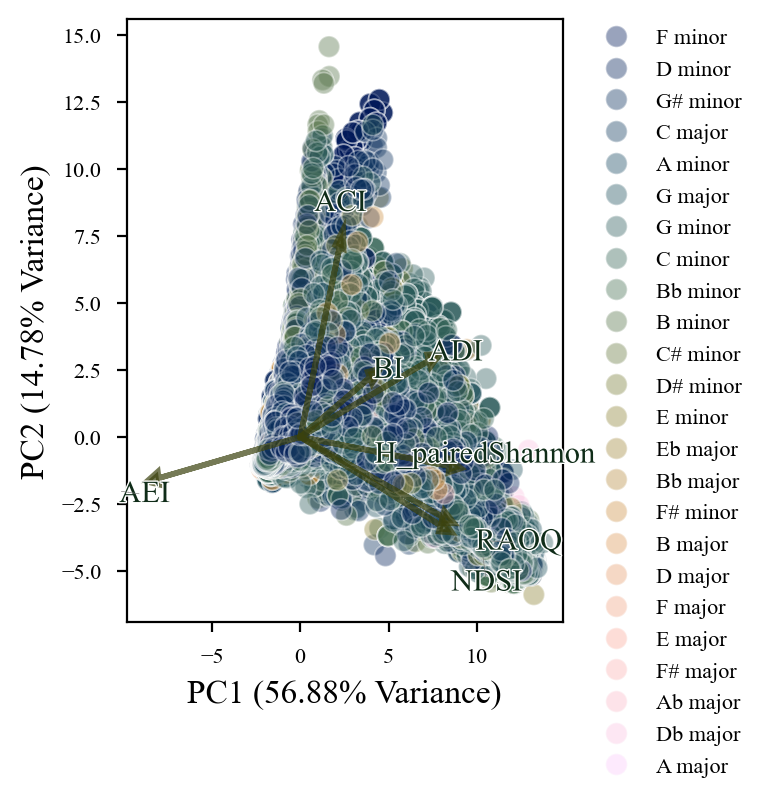

In [32]:
from palettable.scientific.sequential import Batlow_7
from adjustText import adjust_text
import matplotlib.patheffects as path_effects


# Convert the colormap to a color palette by sampling colors
palette = sns.color_palette(Batlow_7.mpl_colormap(np.linspace(0, 1, np.unique(df['Dominant_Key'].values).shape[0]) ))


plt.figure(figsize=(4, 4))
sns.scatterplot(x='PCA1', y='PCA2', hue='Key', data=pca_df, palette=palette, s=60, alpha=0.4)

# Move legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0,frameon=False)

# Store text objects for adjustment
texts = []
# Get the loadings (directions of each variable)
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

# Scale factor for arrows to increase their length
scale_factor = 10
# Add arrows and variable names
for i, var in enumerate(columns):
    plt.arrow(0, 0, loadings[i, 0] * scale_factor, loadings[i, 1] * scale_factor, 
              color='#3B420E', alpha=0.7, head_width=0.5, head_length=0.7, linewidth=2, length_includes_head=True)
    
    # Adjust the text position based on scaled loadings
    text = plt.text(loadings[i, 0] * scale_factor * 1.2, loadings[i, 1] * scale_factor * 1.2, 
                    var, color='#0F2C18', ha='center', va='center', fontsize=11)
        # Add white outline (stroke) around the text
    text.set_path_effects([path_effects.Stroke(linewidth=1, foreground='white'),
                           path_effects.Normal()])
    
    # Collect text objects for adjustment
    texts.append(text)

# Adjust text positions to avoid overlaps (allow more movement freedom)
adjust_text(texts, only_move={'points': 'all', 'texts': 'all'}, expand_points=(1.5, 1.5), 
            expand_text=(1.5, 1.5), lim=500, arrowprops=dict(arrowstyle='-', color='gray'))


# Label axes with explained variance
explained_variance = pca.explained_variance_ratio_
plt.xlabel(f'PC1 ({explained_variance[0]*100:.2f}% Variance)', fontsize=12)
plt.ylabel(f'PC2 ({explained_variance[1]*100:.2f}% Variance)', fontsize=12)

# 调整布局和保存
plt.tight_layout()
plt.savefig('PCA and Key.jpg',dpi=400)

plt.show()

In [5]:
# Generate random data for two heatmaps
data1 = np.random.rand(9, 4)
data2 = np.random.rand(9, 4)

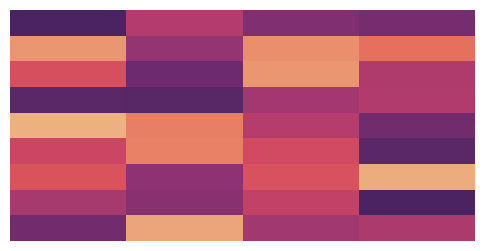

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(6, 3))
sns.heatmap(data1, ax=ax, cmap=sns.color_palette("flare", as_cmap=True), cbar=False)
ax.grid(False)
# 关闭坐标轴和网格
ax.axis('off')     # 关闭坐标轴
plt.savefig('heatmaps1.jpg', dpi=400, transparent=True, bbox_inches='tight', pad_inches=0)

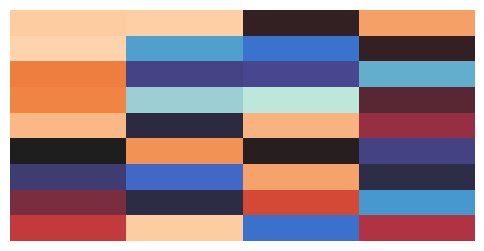

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(6, 3))
sns.heatmap(data2, ax=ax, cmap=sns.color_palette("icefire", as_cmap=True), cbar=False)
ax.grid(False)
# 关闭坐标轴和网格
ax.axis('off')     # 关闭坐标轴
plt.savefig('heatmaps2.jpg', dpi=400, transparent=True, bbox_inches='tight', pad_inches=0)

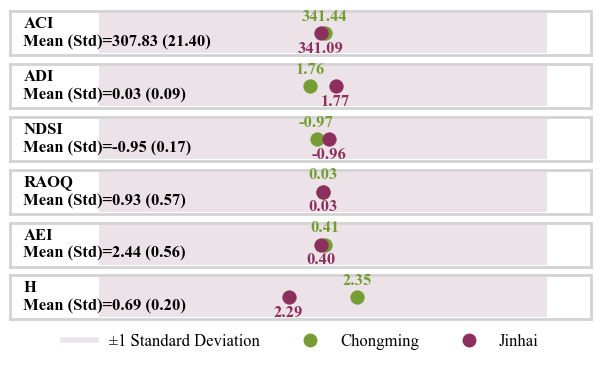

In [12]:
indicators = ['ACI', 'ADI', 'NDSI', 'RAOQ', 'AEI', 'H']
chongming = [341.44, 1.76, -0.97, 0.03, 0.41, 2.35]
jinhai = [341.09, 1.77, -0.96, 0.03, 0.40, 2.29]
means = [307.83, 0.03, -0.95, 0.93, 2.44, 0.69]
std_devs = [21.401, 0.089, 0.174, 0.572, 0.562, 0.195]

# 初始化图像，并调整子图间的垂直间距
fig, axes = plt.subplots(len(indicators), 1, figsize=(7.5, 4))

for i, (indicator, ax) in enumerate(zip(indicators, axes)):
    meanplot = np.mean([chongming[i], jinhai[i]])

    # 为每个指标创建自己的x轴
    min_x = meanplot - std_devs[i]
    max_x = meanplot + std_devs[i]

    # 背景条显示均值 ± 标准差
    ax.barh(0, 2*std_devs[i], left=meanplot-std_devs[i], color='#ECE3E8', height=0.2, edgecolor='none')

    # 在背景条左侧标注Mean值
    ax.text(meanplot-std_devs[i]- (max_x - min_x) * 0.17 , 0, f'{indicators[i]}\nMean (Std)={means[i]:.2f} ({std_devs[i]:.2f})', 
            color='black', va='center', ha='left', fontsize=12, fontweight='bold')

    # 绘制崇明和金海的实际值
    ax.scatter(chongming[i], 0, color='#759D34', s=100, label='Chongming' if i == 0 else "")
    ax.scatter(jinhai[i], 0, color='#8D2F5D', s=100, label='Jinhai' if i == 0 else "")

    # 在图上标注数值
    ax.text(chongming[i], +0.08, f'{chongming[i]:.2f}', color='#759D34', va='center', ha='center', fontsize=12, fontweight='bold')
    ax.text(jinhai[i], -0.08, f'{jinhai[i]:.2f}', color='#8D2F5D', va='center', ha='center', fontsize=12, fontweight='bold')

    # 设置x轴范围
    ax.set_xlim(min_x - (max_x - min_x) * 0.2, max_x + (max_x - min_x) * 0.1)

    # 隐藏y轴和x轴的标签
    ax.yaxis.set_visible(False)
    ax.xaxis.set_visible(False)

    # 修改子图边框颜色和宽度
    for spine in ax.spines.values():
        spine.set_edgecolor('lightgrey')  # 设置边框颜色为灰白色
        spine.set_linewidth(2)  # 设置边框宽度为2


# 创建自定义图例，包括±标准差和地点分类
custom_lines = [plt.Line2D([0], [0], color='#ECE3E8', lw=4),
                plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#759D34', markersize=10),
                plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#8D2F5D', markersize=10)]

fig.legend(custom_lines, ['±1 Standard Deviation', 'Chongming', 'Jinhai'], loc='lower center', 
           frameon=False, fontsize=12, ncol=3)

# 调整子图间距
plt.subplots_adjust(hspace=0.2)
fig.savefig('情况对比.svg',transparent=True)
plt.show()